In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metrics = [
  "loadLatencyDist::mean",
  "vALUInsts",
  "groupReads",
  "groupWrites",
  "ldsBankAccesses",
  "totalCycles",
  "vpc"
]

result_dir = Path("results/task1")
results = []

for folder_name in [f.name for f in result_dir.iterdir() if f.is_dir()]:
    stats_file_path = result_dir / folder_name / "stats.txt"
    
    if not stats_file_path.exists():
        print(f"Warning: {stats_file_path} not found. Skipping.")
        continue
    
    data = {'folder': folder_name.replace("_stats","").replace("CU_", "")}
    
    with open(stats_file_path, "r") as f:
        content = f.read()
        
        for metric in metrics:
            match = re.search(rf".{metric}\s+([0-9]+)", content)
            if match:
                value = int(match.group(1))
                if value == 0 or np.isnan(value):
                    data[metric] = None
                else:
                    data[metric] = value
            else:
                data[metric] = None
    results.append(data)

df = pd.DataFrame(results)
print(df)


    folder  loadLatencyDist::mean  vALUInsts  groupReads  groupWrites  \
0  2_naive                6150276      22528         NaN          NaN   
1    2_opt                 802090      28672      2048.0       2048.0   
2  4_naive               12387336      11264         NaN          NaN   
3    4_opt                1660683      14336      1024.0       1024.0   
4  8_naive               24228370       5632         NaN          NaN   
5    8_opt                4108498       7168       512.0        512.0   

   ldsBankAccesses  totalCycles   vpc  
0              NaN       827193   3.0  
1         393216.0       227563  21.0  
2              NaN       810704   1.0  
3         196608.0       175657  14.0  
4              NaN       791750   NaN  
5          98304.0       174481   7.0  


In [2]:
df

,folder,loadLatencyDist::mean,vALUInsts,groupReads,groupWrites,ldsBankAccesses,totalCycles,vpc
0,2_naive,6150276,22528,NaN,NaN,NaN,827193,3.0
1,2_opt,802090,28672,2048.0,2048.0,393216.0,227563,21.0
2,4_naive,12387336,11264,NaN,NaN,NaN,810704,1.0
3,4_opt,1660683,14336,1024.0,1024.0,196608.0,175657,14.0
4,8_naive,24228370,5632,NaN,NaN,NaN,791750,NaN
5,8_opt,4108498,7168,512.0,512.0,98304.0,174481,7.0


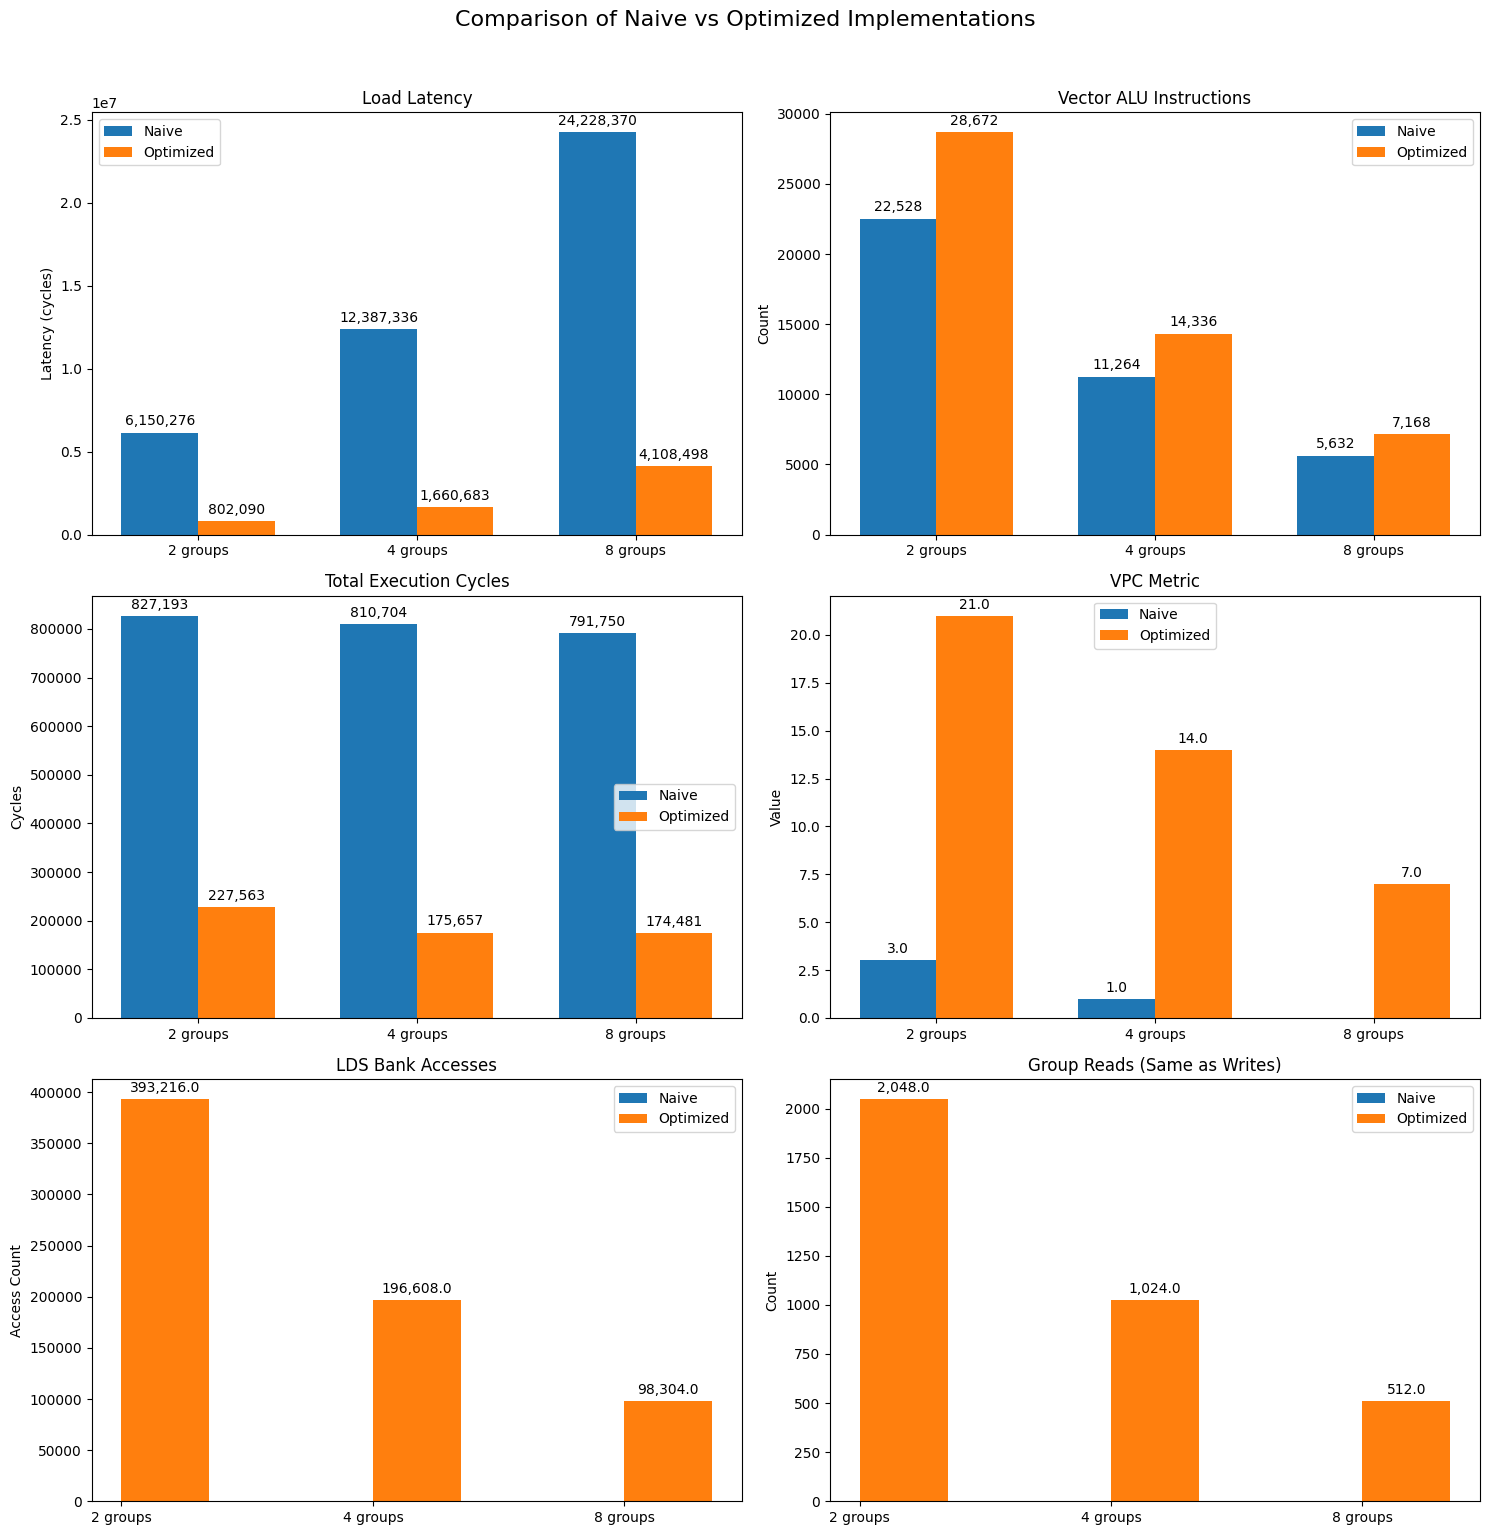

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.suptitle('Comparison of Naive vs Optimized Implementations', fontsize=16, y=1.02)

# Extract the unique group sizes (2,4,8)
group_sizes = sorted(set([int(f.split('_')[0]) for f in df['folder']]))
naive_data = df[df['folder'].str.contains('naive')].sort_values(by='folder')
opt_data = df[df['folder'].str.contains('opt')].sort_values(by='folder')

# Metric pairs to plot (metric, ylabel, title)
metrics_to_plot = [
    ('loadLatencyDist::mean', 'Latency (cycles)', 'Load Latency'),
    ('vALUInsts', 'Count', 'Vector ALU Instructions'),
    ('totalCycles', 'Cycles', 'Total Execution Cycles'),
    ('vpc', 'Value', 'VPC Metric'),
    ('ldsBankAccesses', 'Access Count', 'LDS Bank Accesses'),
    ('groupReads', 'Count', 'Group Reads (Same as Writes)')
]

# Plot each metric
for i, (metric, ylabel, title) in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    
    # Skip if metric not available
    if metric not in df.columns or df[metric].isnull().all():
        ax.axis('off')
        continue
    
    # Get data for naive and optimized
    naive_vals = naive_data[metric].values
    opt_vals = opt_data[metric].values
    
    # Plot bars
    width = 0.35
    x = np.arange(len(group_sizes))
    bars1 = ax.bar(x - width/2, naive_vals, width, label='Naive', color='tab:blue')
    bars2 = ax.bar(x + width/2, opt_vals, width, label='Optimized', color='tab:orange')
    
    # Add labels and titles
    ax.set_xticks(x)
    ax.set_xticklabels([f'{gs} groups' for gs in group_sizes])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    
    # Add value labels on top of bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:,}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

# Adjust layout
plt.tight_layout()

# Save and show
plt.savefig('naive_vs_opt_comparison.png', bbox_inches='tight')
plt.show()

In [15]:
formatted_df = df.copy()

# Apply scientific notation formatting to numeric columns
for col in formatted_df.select_dtypes(include=[np.number]):
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.1e}" if pd.notnull(x) else "-")

# Use default to_latex() with minimal formatting
latex_output = formatted_df.to_latex(
    index=False,
    caption='Performance Comparison (Scientific Notation)',
    label='tab:results',
    position='h!',
    escape=False  # Needed to render the scientific notation properly
)

print(latex_output)


\begin{table}[h!]
\caption{Performance Comparison (Scientific Notation)}
\label{tab:results}
\begin{tabular}{llllllll}
\toprule
folder & loadLatencyDist::mean & vALUInsts & groupReads & groupWrites & ldsBankAccesses & totalCycles & vpc \\
\midrule
2_naive & 6.2e+06 & 2.3e+04 & - & - & - & 8.3e+05 & 3.0e+00 \\
2_opt & 8.0e+05 & 2.9e+04 & 2.0e+03 & 2.0e+03 & 3.9e+05 & 2.3e+05 & 2.1e+01 \\
4_naive & 1.2e+07 & 1.1e+04 & - & - & - & 8.1e+05 & 1.0e+00 \\
4_opt & 1.7e+06 & 1.4e+04 & 1.0e+03 & 1.0e+03 & 2.0e+05 & 1.8e+05 & 1.4e+01 \\
8_naive & 2.4e+07 & 5.6e+03 & - & - & - & 7.9e+05 & - \\
8_opt & 4.1e+06 & 7.2e+03 & 5.1e+02 & 5.1e+02 & 9.8e+04 & 1.7e+05 & 7.0e+00 \\
\bottomrule
\end{tabular}
\end{table}

